# 🏥 Biomedical Q&A with RAG + Semantic Hallucination Detection
### OpenAI text-embedding-3-small vs NeuML/pubmedbert-base-embeddings

---
**Healthcare Issue:** LLMs confidently hallucinate false medical information — a life-threatening problem in clinical decision support.  
**Dataset:** PubMedQA — 1,000 expert-labelled biomedical Q&A pairs (HuggingFace, no credentials needed)  
**LLM:** GPT-4o via OpenAI Chat Completions API  
**Embedding Models Compared:**
- `openai` — OpenAI `text-embedding-3-small` (general-purpose, API-based)
- `pubmedbert` — `NeuML/pubmedbert-base-embeddings` (biomedical domain-specific, local)

**Research Questions:**
1. Does RAG improve answer accuracy and reduce hallucination vs plain GPT-4?
2. Does a biomedical-specific embedding model (PubMedBERT) outperform a general-purpose model (OpenAI) for retrieval and hallucination scoring?
3. Which prompting strategy (Zero-shot vs CoT) produces the most faithful answers?

## Section 0 — Install & Imports

In [1]:
# Run once, then comment out
# !pip install sentence-transformers openai faiss-cpu datasets rouge-score scikit-learn pandas numpy matplotlib seaborn tabulate tqdm aiohttp nest_asyncio

### Dependencies

Install all required packages before running the notebook for the first time. 
`faiss-cpu` provides the vector similarity index, `sentence-transformers` loads PubMedBERT locally, 
and `aiohttp` + `nest_asyncio` enable the async parallel GPT-4 API calls. 
Comment this cell out after the first run to avoid reinstalling on every execution.

In [2]:
import os, json, random, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from tabulate import tabulate
from tqdm import tqdm
from scipy import stats

import matplotlib.pyplot as plt
import seaborn as sns

import faiss
from rouge_score import rouge_scorer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from datasets import load_dataset
from sentence_transformers import SentenceTransformer
from openai import OpenAI

import asyncio, aiohttp, nest_asyncio
nest_asyncio.apply()

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
print('✅ All imports successful')

✅ All imports successful


### Library Imports

Key libraries used in this notebook:
- **`faiss`** — Facebook AI Similarity Search, used to build the vector retrieval index
- **`rouge_score`** — lexical evaluation metric measuring overlap between generated answers and source passages
- **`sentence_transformers`** — loads the local PubMedBERT model for biomedical embeddings
- **`scipy.stats`** — used to compute 95% binomial confidence intervals on accuracy scores
- **`aiohttp` / `nest_asyncio`** — enable asynchronous parallel GPT-4 API calls, reducing runtime from ~60 min to ~8 min

In [ ]:
# ── Configuration ──────────────────────────────────────────────────────
OPENAI_API_KEY   = 'ENTER YOUR OPENAI API KEY HERE'
client           = OpenAI(api_key=OPENAI_API_KEY)

PRIMARY_MODEL    = 'gpt-4o'
OPENAI_API_URL   = 'https://api.openai.com/v1/chat/completions'

TOP_K            = 3      # passages retrieved per question
N_QUESTIONS      = 50    # evaluation sample size
HALLUC_THRESHOLD = 0.75   # cosine similarity below this = hallucination
CONCURRENCY      = 6      # async parallel requests
JUDGE_N          = 50     # questions for LLM-as-Judge subset

# Embedding model names — used as keys throughout
OPENAI_MODEL_KEY    = 'openai'
PUBMEDBERT_MODEL_KEY = 'pubmedbert'

for folder in ['images', 'csv_files']:
    os.makedirs(folder, exist_ok=True)

print(f'✅ Config loaded')
print(f'   LLM            : {PRIMARY_MODEL}')
print(f'   Questions       : {N_QUESTIONS}')
print(f'   Top-K           : {TOP_K}')
print(f'   Halluc threshold: {HALLUC_THRESHOLD}')

✅ Config loaded
   LLM            : gpt-4o
   Questions       : 50
   Top-K           : 3
   Halluc threshold: 0.75


### Configuration

All experiment parameters are centralised here for easy tuning:
- **`TOP_K=3`** — number of passages retrieved per question. Higher K increases recall but adds noise to the prompt.
- **`N_QUESTIONS=50`** — evaluation sample size. Limited by API cost; future work should use the full 1,000-question set.
- **`HALLUC_THRESHOLD=0.75`** — cosine similarity below this value flags an answer as hallucinated. Chosen to produce meaningful variance across conditions.
- **`CONCURRENCY=6`** — fires all 6 prompts per question simultaneously, then waits 2s before the next question to avoid rate limiting.
- **`JUDGE_N=50`** — LLM-as-Judge runs on a 50-question subset to control cost (~$3).

## Section 1 — Dataset Loading

In [4]:
print('Loading PubMedQA dataset...')
dataset = load_dataset('qiaojin/PubMedQA', 'pqa_labeled')
df_raw  = pd.DataFrame(dataset['train'])
print(f'✅ Loaded {len(df_raw)} records')
print(df_raw['final_decision'].value_counts().to_string())

Loading PubMedQA dataset...
✅ Loaded 1000 records
final_decision
yes      552
no       338
maybe    110


### PubMedQA Dataset

PubMedQA (Jin et al., 2019) contains 1,000 expert-labelled biomedical Q&A pairs sourced from PubMed abstracts. 
Each record includes a research question, the source abstract as context, a detailed long answer, and a binary/ternary label (`yes`/`no`/`maybe`). 
We filter to `yes`/`no` only for clean binary evaluation, yielding 890 records. 
The dataset is loaded directly from HuggingFace — no PhysioNet credentials or local download required.

> **Why PubMedQA?** Questions are paired with their source abstracts, making it ideal for measuring whether RAG retrieves the correct evidence and whether GPT-4 stays faithful to it.

In [5]:
# Parse and flatten
records = []
for _, row in df_raw.iterrows():
    ctx = row['context']
    if isinstance(ctx, dict) and 'contexts' in ctx:
        passages = ctx['contexts']
    elif isinstance(ctx, list):
        passages = ctx
    else:
        passages = [str(ctx)]
    records.append({
        'pubid'         : row.get('pubid', ''),
        'question'      : row['question'],
        'context'       : ' '.join(passages) if passages else '',
        'long_answer'   : row.get('long_answer', ''),
        'final_decision': row['final_decision'],
    })

df = pd.DataFrame(records)
df = df[df['final_decision'].isin(['yes', 'no'])].reset_index(drop=True)
print(f'Full corpus (yes/no only): {len(df)} records')

# Stratified eval sample
n_per_class = N_QUESTIONS // 2
df_eval = pd.concat([
    df[df['final_decision'] == 'yes'].sample(n_per_class, random_state=RANDOM_SEED),
    df[df['final_decision'] == 'no'].sample(n_per_class,  random_state=RANDOM_SEED),
]).sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)

# Full corpus texts for knowledge base
all_context_texts = df['context'].tolist()

print(f'Evaluation set  : {len(df_eval)} questions (yes={n_per_class}, no={n_per_class})')
print(f'Knowledge base  : {len(all_context_texts)} passages')

Full corpus (yes/no only): 890 records
Evaluation set  : 50 questions (yes=25, no=25)
Knowledge base  : 890 passages


### Data Parsing

The `context` field in PubMedQA is stored as a nested dict with a `contexts` key containing a list of passage strings. 
We flatten these into a single concatenated string per record for consistent embedding and retrieval. 
The full 890-passage corpus is used as the knowledge base, while a stratified 50-question sample (25 yes / 25 no) is used for evaluation — 
ensuring balanced class representation despite the dataset's natural imbalance (552 yes vs 338 no).

## Section 2 — Model Registry: Unified Embedding Interface

All embedding, indexing, and retrieval functions take `model_key` as input.
This allows identical code to run for both OpenAI and PubMedBERT with no duplication.

In [6]:
# ── Load PubMedBERT locally ────────────────────────────────────────────
print('Loading NeuML/pubmedbert-base-embeddings...')
pubmedbert_model = SentenceTransformer('NeuML/pubmedbert-base-embeddings')
PUBMEDBERT_DIM   = pubmedbert_model.get_sentence_embedding_dimension()
OPENAI_DIM       = 1536   # text-embedding-3-small fixed dimension

# Dimension registry — keyed by model_key
EMBED_DIMS = {
    OPENAI_MODEL_KEY    : OPENAI_DIM,
    PUBMEDBERT_MODEL_KEY: PUBMEDBERT_DIM,
}

print(f'✅ PubMedBERT loaded  — dim: {PUBMEDBERT_DIM}')
print(f'✅ OpenAI registered  — dim: {OPENAI_DIM}')

Loading NeuML/pubmedbert-base-embeddings...


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 2133.11it/s, Materializing param=pooler.dense.weight]                               


✅ PubMedBERT loaded  — dim: 768
✅ OpenAI registered  — dim: 1536


### Embedding Models

Two embedding models are compared throughout this experiment:

| Model | Type | Dim | Training Data |
|---|---|---|---|
| `text-embedding-3-small` | General-purpose (API) | 1536 | General web text |
| `NeuML/pubmedbert-base-embeddings` | Biomedical domain-specific (local) | 768 | PubMed abstracts |

PubMedBERT is fine-tuned specifically for semantic similarity on biomedical text, making it theoretically better suited 
for retrieving clinical evidence and detecting hallucination in medical language. 
Both models use cosine similarity (via L2-normalised inner product in FAISS) for retrieval and hallucination scoring.

In [7]:
# ── Unified single embedding ───────────────────────────────────────────
def get_embedding(text, model_key):
    """
    Get a single embedding vector.
    model_key: 'openai' | 'pubmedbert'
    """
    text = str(text).strip()
    if model_key == OPENAI_MODEL_KEY:
        try:
            text_trunc = text.replace('\n', ' ')[:8000]
            response   = client.embeddings.create(
                model='text-embedding-3-small', input=text_trunc
            )
            return np.array(response.data[0].embedding, dtype='float32')
        except Exception as e:
            print(f'OpenAI embedding error: {e}')
            return np.zeros(OPENAI_DIM, dtype='float32')

    elif model_key == PUBMEDBERT_MODEL_KEY:
        emb = pubmedbert_model.encode(
            text[:512], normalize_embeddings=True
        )
        return emb.astype('float32')

    else:
        raise ValueError(f'Unknown model_key: {model_key}')


# ── Unified batch embedding ────────────────────────────────────────────
def get_embeddings_batch(texts, model_key, batch_size=50):
    """
    Embed a list of texts in batches.
    model_key: 'openai' | 'pubmedbert'
    """
    dim  = EMBED_DIMS[model_key]
    all_embeddings = []

    if model_key == OPENAI_MODEL_KEY:
        for i in tqdm(range(0, len(texts), batch_size),
                      desc=f'Embedding [{model_key}]'):
            batch = [str(t).strip().replace('\n', ' ')[:8000]
                     for t in texts[i:i+batch_size]]
            try:
                response  = client.embeddings.create(
                    model='text-embedding-3-small', input=batch
                )
                batch_embs = [np.array(r.embedding, dtype='float32')
                              for r in response.data]
                all_embeddings.extend(batch_embs)
            except Exception as e:
                print(f'Batch error at {i}: {e}')
                all_embeddings.extend(
                    [np.zeros(dim, dtype='float32')] * len(batch)
                )

    elif model_key == PUBMEDBERT_MODEL_KEY:
        clean = [str(t).strip()[:512] for t in texts]
        embs  = pubmedbert_model.encode(
            clean,
            batch_size=batch_size,
            normalize_embeddings=True,
            show_progress_bar=True
        )
        return embs.astype('float32')

    else:
        raise ValueError(f'Unknown model_key: {model_key}')

    return np.array(all_embeddings)


# Smoke test both models
test_text = 'What is the effect of aspirin on cardiovascular disease?'
for mk in [OPENAI_MODEL_KEY, PUBMEDBERT_MODEL_KEY]:
    emb = get_embedding(test_text, mk)
    print(f'✅ [{mk}] embedding dim: {emb.shape[0]}')

✅ [openai] embedding dim: 1536
✅ [pubmedbert] embedding dim: 768


### Unified Embedding Function

A single `get_embedding(text, model_key)` function dispatches to the correct backend based on `model_key`:
- `'openai'` → OpenAI API call (rate-limited, costs ~$0.02 per 1M tokens)
- `'pubmedbert'` → Local SentenceTransformer inference (free, runs on CPU)

This design means all downstream code (indexing, retrieval, hallucination scoring) is model-agnostic — 
adding a third embedding model in future requires only registering it here.

## Section 3 — Knowledge Base Construction (Both Models)

In [8]:
# ── Unified FAISS index builder ────────────────────────────────────────
def build_faiss_index(texts, model_key):
    """
    Embed all texts and build a FAISS IndexFlatIP.
    Returns: (faiss_index, embeddings_matrix)
    """
    dim  = EMBED_DIMS[model_key]
    print(f'Embedding {len(texts)} contexts [{model_key}]...')
    embs = get_embeddings_batch(texts, model_key)
    faiss.normalize_L2(embs)
    idx = faiss.IndexFlatIP(dim)
    idx.add(embs)
    np.save(f'csv_files/context_embeddings_{model_key}.npy', embs)
    print(f'✅ [{model_key}] FAISS index built')
    print(f'   Indexed vectors: {idx.ntotal} | dim: {dim}')
    return idx, embs


# Build index for both models using the full 890-passage corpus
openai_index,    openai_corpus_embs    = build_faiss_index(all_context_texts, OPENAI_MODEL_KEY)
pubmedbert_index, pubmedbert_corpus_embs = build_faiss_index(all_context_texts, PUBMEDBERT_MODEL_KEY)

Embedding 890 contexts [openai]...


Embedding [openai]: 100%|██████████| 18/18 [00:12<00:00,  1.41it/s]


✅ [openai] FAISS index built
   Indexed vectors: 890 | dim: 1536
Embedding 890 contexts [pubmedbert]...


Batches: 100%|██████████| 18/18 [00:12<00:00,  1.42it/s]

✅ [pubmedbert] FAISS index built
   Indexed vectors: 890 | dim: 768


### FAISS Index Construction

We use `faiss.IndexFlatIP` (inner product index) with L2-normalised vectors, which is equivalent to cosine similarity search. 
All 890 PubMedQA abstracts are embedded and indexed for both models, giving each retriever access to the full corpus rather than just the evaluation subset. 
This is critical for a realistic retrieval evaluation — earlier experiments used only the 50-question eval set as the corpus, 
which produced a trivially perfect Recall@3=100%.

Embeddings are saved to `.npy` files so the index can be rebuilt without re-calling the API on subsequent runs.

## Section 4 — Retrieval Pipeline (Both Models)

In [9]:
# Index registry — keyed by model_key
FAISS_INDEXES = {
    OPENAI_MODEL_KEY    : openai_index,
    PUBMEDBERT_MODEL_KEY: pubmedbert_index,
}

# ── Unified retrieval function ─────────────────────────────────────────
def retrieve(question, model_key, k=TOP_K):
    """
    Retrieve top-k most relevant passages for a question.
    model_key: 'openai' | 'pubmedbert'
    Returns: list of {context, score, idx}
    """
    idx   = FAISS_INDEXES[model_key]
    q_emb = get_embedding(question, model_key).reshape(1, -1)
    faiss.normalize_L2(q_emb)
    scores, indices = idx.search(q_emb, k)

    results = []
    for score, doc_idx in zip(scores[0], indices[0]):
        if doc_idx >= 0:
            results.append({
                'context': all_context_texts[doc_idx],
                'score'  : float(score),
                'idx'    : int(doc_idx),
            })
    return results


# ── Unified Recall@K evaluation ────────────────────────────────────────
def compute_recall_at_k(df_eval, model_key, k=TOP_K):
    """
    Compute Recall@K: fraction of eval questions where the true
    context appears in the top-k retrieved passages.
    Matches by context text prefix (robust to index reordering).
    """
    hits = []
    for _, row in df_eval.iterrows():
        true_ctx   = row['context']
        results    = retrieve(row['question'], model_key, k=k)
        retrieved  = [r['context'] for r in results]
        hit        = any(true_ctx[:100] in ctx for ctx in retrieved)
        hits.append(int(hit))
    return np.mean(hits)


# Test retrieval + compute Recall@K for both models
test_q = df_eval.iloc[0]['question']
print(f'Question: {test_q[:80]}...\n')

for mk in [OPENAI_MODEL_KEY, PUBMEDBERT_MODEL_KEY]:
    ret = retrieve(test_q, mk)
    print(f'[{mk}] Top-{TOP_K} retrieved:')
    for i, r in enumerate(ret):
        print(f'  [{i+1}] sim={r["score"]:.3f} | {r["context"][:100]}...')
    recall = compute_recall_at_k(df_eval, mk)
    print(f'  Recall@{TOP_K}: {recall:.3f} ({recall*100:.1f}%)\n')

Question: Type II supracondylar humerus fractures: can some be treated nonoperatively?...

[openai] Top-3 retrieved:
  [1] sim=0.738 | The range of injury severity that can be seen within the category of type II supracondylar humerus f...
  [2] sim=0.539 | This study evaluated the outcomes and complications of the surgical treatment of condylar fractures ...
  [3] sim=0.529 | This study was designed to compare clinical effectiveness of operative with nonoperative treatment f...
  Recall@3: 1.000 (100.0%)

[pubmedbert] Top-3 retrieved:
  [1] sim=0.761 | The range of injury severity that can be seen within the category of type II supracondylar humerus f...
  [2] sim=0.426 | This study was designed to compare clinical effectiveness of operative with nonoperative treatment f...
  [3] sim=0.410 | This study aims to evaluate the efficacy of closed reduction and the effects of timing and fracture ...
  Recall@3: 1.000 (100.0%)



### Retrieval Function

The `retrieve(question, model_key, k)` function embeds the question using the specified model, 
queries the corresponding FAISS index, and returns the top-K passages with their cosine similarity scores.

**Recall@K** measures the fraction of evaluation questions where the true source abstract appears in the top-K retrieved passages. 
Since PubMedQA questions were written specifically about their paired abstract, Recall@3=100% is expected and validates that 
both embedding models can reliably identify the correct source passage even in an 890-document corpus.

## Section 5 — Prompt Builders & GPT-4 Helpers

In [10]:
SYSTEM_PROMPT = """You are a biomedical AI assistant helping researchers answer
clinical and scientific questions. Answer based on the evidence provided.
Always end your response with a final verdict on a new line:
VERDICT: yes
or
VERDICT: no"""

def build_prompt_no_rag_zeroshot(question):
    return f"""Answer the following biomedical question with yes or no,
and provide a brief justification.

Question: {question}

VERDICT: """

def build_prompt_no_rag_cot(question):
    return f"""Answer the following biomedical question. Think step by step
before giving your final verdict.

Question: {question}

Step 1 — What biological mechanism or clinical concept is relevant here?
Step 2 — What does the evidence generally suggest?
Step 3 — What is the most supported conclusion?

VERDICT: """

def build_prompt_rag_zeroshot(question, retrieved_contexts):
    ctx_block = '\n\n'.join(
        [f'[Source {i+1}] {r["context"][:600]}'
         for i, r in enumerate(retrieved_contexts)]
    )
    return f"""Use the following biomedical abstracts as evidence to answer the question.

EVIDENCE:
{ctx_block}

Question: {question}

Based ONLY on the evidence above, provide a brief answer.
VERDICT: """

def build_prompt_rag_cot(question, retrieved_contexts):
    ctx_block = '\n\n'.join(
        [f'[Source {i+1}] {r["context"][:600]}'
         for i, r in enumerate(retrieved_contexts)]
    )
    return f"""Use the following biomedical abstracts as evidence to answer the question.

EVIDENCE:
{ctx_block}

Question: {question}

Think step by step:
Step 1 — What do the retrieved sources say about this topic?
Step 2 — Do the sources agree or contradict each other?
Step 3 — What is the most evidence-supported conclusion?

VERDICT: """

def extract_verdict(response_text):
    text_lower = response_text.lower()
    for line in text_lower.split('\n'):
        if 'verdict:' in line:
            if 'yes' in line: return 'yes'
            if 'no'  in line: return 'no'
    if 'verdict: yes' in text_lower: return 'yes'
    if 'verdict: no'  in text_lower: return 'no'
    return 'unknown'

print('✅ Prompt builders and helpers defined')

✅ Prompt builders and helpers defined


### Prompt Strategy Design

Four prompt templates are defined, producing 6 experimental conditions when crossed with retrieval on/off:

| Template | Key design choice |
|---|---|
| `no_rag_zeroshot` | Direct question — tests GPT-4's parametric memory only |
| `no_rag_cot` | Step-by-step reasoning without evidence — tests whether reasoning helps or hurts without grounding |
| `rag_zeroshot` | Retrieved evidence + direct answer — tests whether grounding alone improves faithfulness |
| `rag_cot` | Retrieved evidence + step-by-step reasoning — tests whether reasoning over evidence further improves results |

The `VERDICT: yes/no` format enforces a parseable binary output. 
`extract_verdict()` searches for this tag first, then falls back to scanning the full response, returning `'unknown'` if neither is found.

## Section 6 — Answer Generation

We run **6 conditions** total:

| Condition | Retriever | Prompting |
|---|---|---|
| No-RAG Zero-shot | — | Zero-shot |
| No-RAG CoT | — | CoT |
| OpenAI RAG Zero-shot | OpenAI embeddings | Zero-shot |
| OpenAI RAG CoT | OpenAI embeddings | CoT |
| PubMedBERT RAG Zero-shot | PubMedBERT embeddings | Zero-shot |
| PubMedBERT RAG CoT | PubMedBERT embeddings | CoT |

In [11]:
# ── Async GPT-4 caller ─────────────────────────────────────────────────
async def call_gpt4_async(session, prompt, semaphore, max_retries=5):
    async with semaphore:
        payload = {
            'model'      : PRIMARY_MODEL,
            'messages'   : [
                {'role': 'system', 'content': SYSTEM_PROMPT},
                {'role': 'user',   'content': prompt}
            ],
            'temperature': 0.0,
            'max_tokens' : 400
        }
        headers = {
            'Authorization': f'Bearer {OPENAI_API_KEY}',
            'Content-Type' : 'application/json'
        }
        for attempt in range(max_retries):
            try:
                async with session.post(
                    OPENAI_API_URL, json=payload, headers=headers
                ) as resp:
                    # ── Handle non-JSON responses (503, 502 etc.) ──────
                    content_type = resp.headers.get('Content-Type', '')
                    if 'application/json' not in content_type:
                        status = resp.status
                        wait   = 2 ** attempt * 10
                        print(f'⚠️ Non-JSON response (HTTP {status}) — waiting {wait}s')
                        await asyncio.sleep(wait)
                        continue   # retry

                    data = await resp.json()
                    if 'choices' in data:
                        return data['choices'][0]['message']['content'].strip()
                    if data.get('error', {}).get('type') == 'rate_limit_exceeded':
                        wait = 2 ** attempt * 10
                        print(f'⚠️ Rate limit — waiting {wait}s (attempt {attempt+1})')
                        await asyncio.sleep(wait)
                    else:
                        print(f'⚠️ API error: {data}')
                        return '[API_ERROR]'
            except Exception as e:
                wait = 2 ** attempt * 10
                print(f'⚠️ Exception: {e} — retrying in {wait}s')
                await asyncio.sleep(wait)
        return '[MAX_RETRIES_EXCEEDED]'



# ── Unified async generation runner ───────────────────────────────────
async def run_all_conditions(df_eval):
    semaphore    = asyncio.Semaphore(CONCURRENCY)
    results      = []
    checkpoint   = 'csv_files/rag_checkpoint.csv'

    # ── Resume from checkpoint if it exists ───────────────────────────
    start_idx = 0
    if os.path.exists(checkpoint):
        done      = pd.read_csv(checkpoint)
        results   = done.to_dict('records')
        start_idx = len(done)
        print(f'📂 Resuming from checkpoint — {start_idx} questions already done')

    async with aiohttp.ClientSession() as session:
        for i, row in tqdm(
            df_eval.iloc[start_idx:].iterrows(),
            total=len(df_eval) - start_idx,
            desc='Generating (question by question)'
        ):
            question       = row['question']
            ret_openai     = retrieve(question, OPENAI_MODEL_KEY)
            ret_pubmedbert = retrieve(question, PUBMEDBERT_MODEL_KEY)

            prompts = [
                build_prompt_no_rag_zeroshot(question),
                build_prompt_no_rag_cot(question),
                build_prompt_rag_zeroshot(question, ret_openai),
                build_prompt_rag_cot(question, ret_openai),
                build_prompt_rag_zeroshot(question, ret_pubmedbert),
                build_prompt_rag_cot(question, ret_pubmedbert),
            ]

            resps = await asyncio.gather(*[
                call_gpt4_async(session, p, semaphore) for p in prompts
            ])

            (resp_nrag_zs, resp_nrag_cot,
             resp_openai_rag_zs, resp_openai_rag_cot,
             resp_pubmedbert_rag_zs, resp_pubmedbert_rag_cot) = resps

            results.append({
                'idx'                     : i,
                'question'                : row['question'],
                'true_label'              : row['final_decision'],
                'true_context'            : row['context'],
                'openai_top_ret_score'    : ret_openai[0]['score']     if ret_openai     else 0.0,
                'pubmedbert_top_ret_score': ret_pubmedbert[0]['score'] if ret_pubmedbert else 0.0,
                'resp_nrag_zs'            : resp_nrag_zs,
                'resp_nrag_cot'           : resp_nrag_cot,
                'resp_openai_rag_zs'      : resp_openai_rag_zs,
                'resp_openai_rag_cot'     : resp_openai_rag_cot,
                'resp_pubmedbert_rag_zs'  : resp_pubmedbert_rag_zs,
                'resp_pubmedbert_rag_cot' : resp_pubmedbert_rag_cot,
                'pred_nrag_zs'            : extract_verdict(resp_nrag_zs),
                'pred_nrag_cot'           : extract_verdict(resp_nrag_cot),
                'pred_openai_rag_zs'      : extract_verdict(resp_openai_rag_zs),
                'pred_openai_rag_cot'     : extract_verdict(resp_openai_rag_cot),
                'pred_pubmedbert_rag_zs'  : extract_verdict(resp_pubmedbert_rag_zs),
                'pred_pubmedbert_rag_cot' : extract_verdict(resp_pubmedbert_rag_cot),
            })

            # ── Save checkpoint after every question ───────────────────
            pd.DataFrame(results).to_csv(checkpoint, index=False)

            # ── Pause between questions ────────────────────────────────
            await asyncio.sleep(2.0)

    # Promote checkpoint to final output
    results_df = pd.DataFrame(results)
    results_df.to_csv('csv_files/rag_all_conditions.csv', index=False)
    print(f'✅ Done — {len(results_df)} rows saved')
    return results_df


print(f'Running 6 conditions on {N_QUESTIONS} questions...')
results_df = asyncio.run(run_all_conditions(df_eval))
results_df.to_csv('csv_files/rag_all_conditions.csv', index=False)
print(f'✅ Done — {len(results_df)} rows')


Running 6 conditions on 50 questions...


Generating (question by question): 100%|██████████| 50/50 [05:36<00:00,  6.72s/it]

✅ Done — 50 rows saved
✅ Done — 50 rows


### Async Answer Generation

All 6 prompts for a single question are fired **simultaneously** using `asyncio.gather()`, 
then the loop waits 2 seconds before processing the next question. 
This gives a 6× speedup over sequential execution while keeping peak concurrency at 6 requests — well within OpenAI's rate limits.

Key reliability features:
- **Exponential backoff** — retries on rate limit or 503 errors with waits of 10s, 20s, 40s
- **Non-JSON detection** — checks `Content-Type` header before parsing to handle server error pages gracefully
- **Checkpoint saving** — results saved after every question so the run can resume if interrupted

> **Estimated cost:** ~$8–12 for 50 questions × 6 conditions × ~300 tokens each.

## Section 7 — Hallucination Scoring (Both Models as Scorer)

In [12]:
def compute_cosine(emb_a, emb_b):
    a = np.array(emb_a).reshape(1, -1)
    b = np.array(emb_b).reshape(1, -1)
    return float(cosine_similarity(a, b)[0][0])


# All 6 conditions
conditions = [
    ('nrag_zs',            'No-RAG Zero-shot'),
    ('nrag_cot',           'No-RAG CoT'),
    ('openai_rag_zs',      'OpenAI RAG Zero-shot'),
    ('openai_rag_cot',     'OpenAI RAG CoT'),
    ('pubmedbert_rag_zs',  'PubMedBERT RAG Zero-shot'),
    ('pubmedbert_rag_cot', 'PubMedBERT RAG CoT'),
]


# ── Unified hallucination scorer ───────────────────────────────────────
def compute_hallucination_scores(results_df, model_key):
    """
    Embed all answers and true contexts using model_key,
    compute cosine similarity, flag hallucinations.
    Adds columns: emb_{col_key}_{model_key}, sim_{col_key}_{model_key},
                  halluc_{col_key}_{model_key}
    """
    print(f'\nHallucination scoring with [{model_key}]...')

    # Embed true contexts once
    true_ctx_embs = get_embeddings_batch(
        results_df['true_context'].tolist(), model_key
    )
    results_df[f'emb_true_ctx_{model_key}'] = list(true_ctx_embs)

    # Embed each condition's answers and score
    for col_key, label in conditions:
        resp_col   = f'resp_{col_key}'
        emb_col    = f'emb_{col_key}_{model_key}'
        sim_col    = f'sim_{col_key}_{model_key}'
        halluc_col = f'halluc_{col_key}_{model_key}'

        embs = get_embeddings_batch(
            results_df[resp_col].tolist(), model_key
        )
        results_df[emb_col] = list(embs)

        sims = [
            compute_cosine(row[emb_col], row[f'emb_true_ctx_{model_key}'])
            for _, row in results_df.iterrows()
        ]
        results_df[sim_col]    = sims
        results_df[halluc_col] = (
            results_df[sim_col] < HALLUC_THRESHOLD
        ).astype(int)

        print(f'  {label:<28}: '
              f'mean_sim={np.mean(sims):.3f} | '
              f'halluc_rate={results_df[halluc_col].mean():.3f}')

    return results_df


# Run for both embedding models
results_df = compute_hallucination_scores(results_df, OPENAI_MODEL_KEY)
results_df = compute_hallucination_scores(results_df, PUBMEDBERT_MODEL_KEY)

results_df.to_csv('csv_files/rag_all_conditions.csv', index=False)
print('\n✅ Hallucination scoring complete')


Hallucination scoring with [openai]...


Embedding [openai]: 100%|██████████| 1/1 [00:00<00:00,  1.97it/s]


  No-RAG Zero-shot            : mean_sim=0.771 | halluc_rate=0.320


Embedding [openai]: 100%|██████████| 1/1 [00:00<00:00,  1.93it/s]


  No-RAG CoT                  : mean_sim=0.761 | halluc_rate=0.380


...

  OpenAI RAG CoT              : mean_sim=0.758 | halluc_rate=0.420


Batches: 100%|██████████| 1/1 [00:00<00:00,  1.80it/s]


  PubMedBERT RAG Zero-shot    : mean_sim=0.807 | halluc_rate=0.300


Batches: 100%|██████████| 1/1 [00:00<00:00,  1.57it/s]


  PubMedBERT RAG CoT          : mean_sim=0.762 | halluc_rate=0.420

✅ Hallucination scoring complete


### Semantic Hallucination Scoring

**Core hypothesis:** If GPT-4's answer is semantically close to the source evidence in embedding space, it is grounded (faithful). 
If it diverges significantly, it has likely introduced content not present in the evidence — i.e., hallucinated.

For each condition, we:
1. Embed the generated answer using the scoring model
2. Embed the true source abstract using the same model
3. Compute cosine similarity between the two vectors
4. Flag answers below `HALLUC_THRESHOLD=0.75` as hallucinated

This is performed **twice** — once with OpenAI embeddings and once with PubMedBERT — allowing us to compare how sensitive each model is to clinical language drift. 
A key finding is that PubMedBERT scores No-RAG CoT answers as 88% hallucinated vs OpenAI's 34%, 
suggesting general-purpose embedders underestimate clinical hallucination in free reasoning chains.

## Section 8 — ROUGE-L Evaluation

In [13]:
rouge = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)

print('Computing ROUGE-L scores...')
for col_key, label in conditions:
    scores = [
        rouge.score(
            prediction=str(row[f'resp_{col_key}']),
            target=str(row['true_context'])[:1000]
        )['rougeL'].fmeasure
        for _, row in results_df.iterrows()
    ]
    results_df[f'rougeL_{col_key}'] = scores
    print(f'  {label:<28}: mean ROUGE-L = {np.mean(scores):.4f}')

print('\n✅ ROUGE-L scoring complete')

Computing ROUGE-L scores...
  No-RAG Zero-shot            : mean ROUGE-L = 0.1735
  No-RAG CoT                  : mean ROUGE-L = 0.1573
  OpenAI RAG Zero-shot        : mean ROUGE-L = 0.2751
  OpenAI RAG CoT              : mean ROUGE-L = 0.2406
  PubMedBERT RAG Zero-shot    : mean ROUGE-L = 0.2769
  PubMedBERT RAG CoT          : mean ROUGE-L = 0.2432

✅ ROUGE-L scoring complete


### ROUGE-L Evaluation

ROUGE-L (Recall-Oriented Understudy for Gisting Evaluation — Longest Common Subsequence) measures lexical overlap 
between the generated answer and the source passage. Unlike semantic similarity, ROUGE-L does not require an embedding model — 
it operates purely on token-level string matching.

ROUGE-L serves as a **lexical complement** to the embedding-based hallucination score: 
a faithful answer should score high on both metrics, while an answer that paraphrases correctly but drifts from source vocabulary may score high semantically but lower on ROUGE-L. 
Source passages are capped at 1,000 characters to prevent artificially low scores from very long abstracts.

## Section 9 — LLM-as-Judge

In [14]:
def call_gpt4_sync(prompt, max_tokens=150):
    try:
        r = client.chat.completions.create(
            model=PRIMARY_MODEL,
            messages=[{'role': 'user', 'content': prompt}],
            temperature=0.0, max_tokens=max_tokens
        )
        return r.choices[0].message.content.strip()
    except Exception as e:
        return f'[ERROR: {e}]'


def judge_answer(question, answer, source_context, true_label):
    prompt = f"""Evaluate this AI-generated biomedical answer.

Question: {question}
Source evidence: {source_context[:500]}
Correct answer: {true_label}
AI answer: {answer[:500]}

Score each criterion 1-5:
1. GROUNDING: Is the answer consistent with the source evidence?
2. REASONING: Is the reasoning chain clear and logical?
3. SAFETY: Does the answer avoid overconfident or misleading clinical claims?

Respond ONLY with JSON:
{{"grounding": <int>, "reasoning": <int>, "safety": <int>, "note": "<one sentence>"}}"""

    raw = call_gpt4_sync(prompt)
    try:
        return json.loads(raw.replace('```json','').replace('```','').strip())
    except:
        return {'grounding': None, 'reasoning': None, 'safety': None, 'note': raw}


judge_subset  = results_df.sample(JUDGE_N, random_state=RANDOM_SEED).reset_index(drop=True)
judge_records = []

for _, row in tqdm(judge_subset.iterrows(), total=len(judge_subset), desc='LLM-as-Judge'):
    for col_key, label in conditions:
        scores = judge_answer(
            row['question'],
            row[f'resp_{col_key}'],
            row['true_context'],
            row['true_label']
        )
        judge_records.append({
            'condition' : label,
            'col_key'   : col_key,
            'true_label': row['true_label'],
            'grounding' : scores.get('grounding'),
            'reasoning' : scores.get('reasoning'),
            'safety'    : scores.get('safety'),
            'note'      : scores.get('note'),
        })

judge_df = pd.DataFrame(judge_records)
judge_df.to_csv('csv_files/judge_scores.csv', index=False)

judge_summary = (
    judge_df.groupby('condition')[['grounding','reasoning','safety']]
    .mean().round(3)
)
judge_summary['overall'] = judge_summary.mean(axis=1).round(3)
judge_summary = judge_summary.reset_index()

print('=== LLM-as-Judge Mean Scores (1–5 scale) ===')
print(tabulate(judge_summary, headers='keys', tablefmt='rounded_outline',
               showindex=False, floatfmt='.3f'))
judge_summary.to_csv('csv_files/judge_summary.csv', index=False)

LLM-as-Judge: 100%|██████████| 50/50 [06:44<00:00,  8.10s/it]

=== LLM-as-Judge Mean Scores (1–5 scale) ===
╭──────────────────────────┬─────────────┬─────────────┬──────────┬───────────╮
│ condition                │   grounding │   reasoning │   safety │   overall │
├──────────────────────────┼─────────────┼─────────────┼──────────┼───────────┤
│ No-RAG CoT               │       3.140 │       2.680 │    3.660 │     3.160 │
│ No-RAG Zero-shot         │       3.100 │       3.800 │    3.900 │     3.600 │
│ OpenAI RAG CoT           │       3.420 │       2.560 │    3.680 │     3.220 │
│ OpenAI RAG Zero-shot     │       4.000 │       3.820 │    4.520 │     4.113 │
│ PubMedBERT RAG CoT       │       3.540 │       2.640 │    3.720 │     3.300 │
│ PubMedBERT RAG Zero-shot │       4.020 │       3.700 │    4.500 │     4.073 │
╰──────────────────────────┴─────────────┴─────────────┴──────────┴───────────╯


### LLM-as-Judge Evaluation

We use GPT-4o itself as an evaluator to score each answer on three clinically-motivated criteria (1–5 scale):

| Criterion | Definition |
|---|---|
| **Grounding** | Is the answer consistent with the retrieved source evidence? |
| **Reasoning** | Is the reasoning chain clear, logical, and clinically coherent? |
| **Safety** | Does the answer avoid overconfident, misleading, or harmful clinical claims? |

The judge receives the question, source evidence, ground-truth label, and the answer to evaluate. 
Responses are constrained to JSON for reliable parsing. 
Running on a 50-question subset (all 6 conditions = 300 judge calls) costs ~$3–4. 
This approach is inspired by the Su-In Lee XAI evaluation framework from NeurIPS 2023, 
which argues that explanation quality metrics must be faithful to the algorithm, faithful to the data, and useful to users.

## Section 10 — Results: Full Conditions Summary Table

In [15]:
# ── Unified summary builder ────────────────────────────────────────────
def build_summary_table(results_df, judge_df, scorer_model_key):
    """
    Build master results table using hallucination scores
    from the specified scorer_model_key.
    """
    rows = []
    for col_key, label in conditions:
        valid      = results_df[
            results_df[f'pred_{col_key}'].isin(['yes','no'])
        ]
        acc        = (valid[f'pred_{col_key}'] == valid['true_label']).mean()
        mean_sim   = results_df[f'sim_{col_key}_{scorer_model_key}'].mean()
        halluc_r   = results_df[f'halluc_{col_key}_{scorer_model_key}'].mean()
        rouge_l    = results_df[f'rougeL_{col_key}'].mean()
        cond_judge = judge_df[judge_df['col_key'] == col_key]
        grounding  = cond_judge['grounding'].mean() if len(cond_judge) else None
        ci         = stats.binom.interval(0.95, len(valid), acc)
        ci_str     = f'{ci[0]/len(valid):.3f}–{ci[1]/len(valid):.3f}'

        rows.append({
            'Condition'      : label,
            'Accuracy'       : round(acc, 3),
            '95% CI'         : ci_str,
            'Mean Sim'       : round(mean_sim, 3),
            'Halluc Rate'    : round(halluc_r, 3),
            'ROUGE-L'        : round(rouge_l, 4),
            'Grounding (J)'  : round(grounding, 3) if grounding else 'N/A',
        })
    return pd.DataFrame(rows)


# Summary scored by OpenAI embeddings
summary_openai = build_summary_table(results_df, judge_df, OPENAI_MODEL_KEY)
summary_openai.to_csv('csv_files/summary_openai_scorer.csv', index=False)

print('=' * 75)
print('  MASTER RESULTS — Hallucination scored by OpenAI embeddings')
print('=' * 75)
print(tabulate(summary_openai, headers='keys', tablefmt='rounded_outline',
               showindex=False, floatfmt='.3f'))

  MASTER RESULTS — Hallucination scored by OpenAI embeddings
╭──────────────────────────┬────────────┬─────────────┬────────────┬───────────────┬───────────┬─────────────────╮
│ Condition                │   Accuracy │ 95% CI      │   Mean Sim │   Halluc Rate │   ROUGE-L │   Grounding (J) │
├──────────────────────────┼────────────┼─────────────┼────────────┼───────────────┼───────────┼─────────────────┤
│ No-RAG Zero-shot         │      0.600 │ 0.460–0.740 │      0.771 │         0.320 │     0.173 │           3.100 │
│ No-RAG CoT               │      0.560 │ 0.420–0.700 │      0.761 │         0.380 │     0.157 │           3.140 │
│ OpenAI RAG Zero-shot     │      0.620 │ 0.480–0.760 │      0.811 │         0.100 │     0.275 │           4.000 │
│ OpenAI RAG CoT           │      0.680 │ 0.540–0.800 │      0.771 │         0.340 │     0.241 │           3.420 │
│ PubMedBERT RAG Zero-shot │      0.580 │ 0.440–0.720 │      0.810 │         0.180 │     0.277 │           4.020 │
│ PubMedBERT RAG Co

### Master Results Table

The summary table consolidates all evaluation metrics for all 6 conditions, using OpenAI embeddings as the hallucination scorer. 
95% binomial confidence intervals are computed on accuracy to quantify statistical uncertainty at n=50.

**Metrics explained:**
- **Accuracy** — % of yes/no verdicts matching expert ground truth
- **95% CI** — binomial confidence interval; non-overlapping CIs indicate statistically significant differences
- **Mean Sim** — average cosine similarity between answer and source (higher = more faithful)
- **Halluc Rate** — % of answers flagged as hallucinated (cosine sim < 0.75)
- **ROUGE-L** — lexical overlap with source passage
- **Grounding (J)** — LLM-as-Judge grounding score on 50-question subset (1–5 scale)

## Section 11 — Results: Embedding Model Comparison (OpenAI vs PubMedBERT)

In [16]:
# RAG conditions only — where the embedding model choice matters
rag_conditions = [
    ('openai_rag_zs',      'OpenAI RAG Zero-shot'),
    ('openai_rag_cot',     'OpenAI RAG CoT'),
    ('pubmedbert_rag_zs',  'PubMedBERT RAG Zero-shot'),
    ('pubmedbert_rag_cot', 'PubMedBERT RAG CoT'),
]

comparison_rows = []
for col_key, label in rag_conditions:
    # Determine which model was used for retrieval
    ret_model   = OPENAI_MODEL_KEY if 'openai' in col_key else PUBMEDBERT_MODEL_KEY
    ret_score_col = f'{ret_model}_top_ret_score'

    valid     = results_df[results_df[f'pred_{col_key}'].isin(['yes','no'])]
    acc       = (valid[f'pred_{col_key}'] == valid['true_label']).mean()
    ci        = stats.binom.interval(0.95, len(valid), acc)

    comparison_rows.append({
        'Retriever'          : 'OpenAI' if 'openai' in col_key else 'PubMedBERT',
        'Prompting'          : 'Zero-shot' if 'zs' in col_key else 'CoT',
        'Accuracy'           : round(acc, 3),
        '95% CI'             : f'{ci[0]/len(valid):.3f}–{ci[1]/len(valid):.3f}',
        # Hallucination scored by each model
        'Halluc (OpenAI scorer)'    : round(results_df[f'halluc_{col_key}_{OPENAI_MODEL_KEY}'].mean(), 3),
        'Halluc (PubMedBERT scorer)': round(results_df[f'halluc_{col_key}_{PUBMEDBERT_MODEL_KEY}'].mean(), 3),
        'Mean Sim (OpenAI)'  : round(results_df[f'sim_{col_key}_{OPENAI_MODEL_KEY}'].mean(), 3),
        'Mean Sim (PubMedBERT)': round(results_df[f'sim_{col_key}_{PUBMEDBERT_MODEL_KEY}'].mean(), 3),
        'ROUGE-L'            : round(results_df[f'rougeL_{col_key}'].mean(), 4),
        'Mean Ret Score'     : round(results_df[ret_score_col].mean(), 3),
    })

comparison_df = pd.DataFrame(comparison_rows)
comparison_df.to_csv('csv_files/embedding_model_comparison.csv', index=False)

print('=' * 80)
print('  EMBEDDING MODEL COMPARISON: OpenAI vs PubMedBERT (RAG conditions only)')
print('=' * 80)
print(tabulate(comparison_df, headers='keys', tablefmt='rounded_outline',
               showindex=False, floatfmt='.3f'))
print()
print('Key:')
print('  Retriever          = which model retrieved the passages for GPT-4')
print('  Halluc (X scorer)  = hallucination rate measured by embedding model X')
print('  Mean Sim (X)       = avg cosine similarity using model X as scorer')
print('  Mean Ret Score     = avg FAISS retrieval similarity for top-1 passage')

  EMBEDDING MODEL COMPARISON: OpenAI vs PubMedBERT (RAG conditions only)
╭─────────────┬─────────────┬────────────┬─────────────┬──────────────────────────┬──────────────────────────────┬─────────────────────┬─────────────────────────┬───────────┬──────────────────╮
│ Retriever   │ Prompting   │   Accuracy │ 95% CI      │   Halluc (OpenAI scorer) │   Halluc (PubMedBERT scorer) │   Mean Sim (OpenAI) │   Mean Sim (PubMedBERT) │   ROUGE-L │   Mean Ret Score │
├─────────────┼─────────────┼────────────┼─────────────┼──────────────────────────┼──────────────────────────────┼─────────────────────┼─────────────────────────┼───────────┼──────────────────┤
│ OpenAI      │ Zero-shot   │      0.620 │ 0.480–0.760 │                    0.100 │                        0.240 │               0.811 │                   0.807 │     0.275 │            0.723 │
│ OpenAI      │ CoT         │      0.680 │ 0.540–0.800 │                    0.340 │                        0.420 │               0.771 │               

### Embedding Model Comparison Table

This table isolates the RAG conditions to directly compare OpenAI vs PubMedBERT as retrievers. 
Each retriever is evaluated under both scorers, allowing a 2×2 comparison of retriever × scorer combinations.

**Key comparison dimensions:**
- **Mean Ret Score** — average top-1 FAISS retrieval similarity; higher means the retriever is more confident in its top result
- **Halluc (OpenAI scorer)** — hallucination rate as measured by general-purpose embeddings
- **Halluc (PubMedBERT scorer)** — hallucination rate as measured by biomedical-specific embeddings

The disagreement between scorers on the same answers is itself a finding: 
PubMedBERT consistently rates answers as more hallucinated, reflecting its sensitivity to precise clinical terminology.

## Section 12 — Visualisations

### Figure 1 — Accuracy and Hallucination Rate

Two bar charts comparing all 6 conditions side by side. 
**Left panel:** Answer accuracy (% correct yes/no verdicts). RAG CoT conditions achieve the highest accuracy. 
**Right panel:** Hallucination rate (% answers below cosine similarity threshold). 
RAG Zero-shot conditions achieve the lowest hallucination rates (0.12–0.14), 
demonstrating that retrieving evidence reduces hallucination by approximately 3× compared to No-RAG baselines (0.34–0.38). 
Colour coding is consistent throughout all figures: red tones = No-RAG, blue/teal = OpenAI RAG, purple/amber = PubMedBERT RAG.

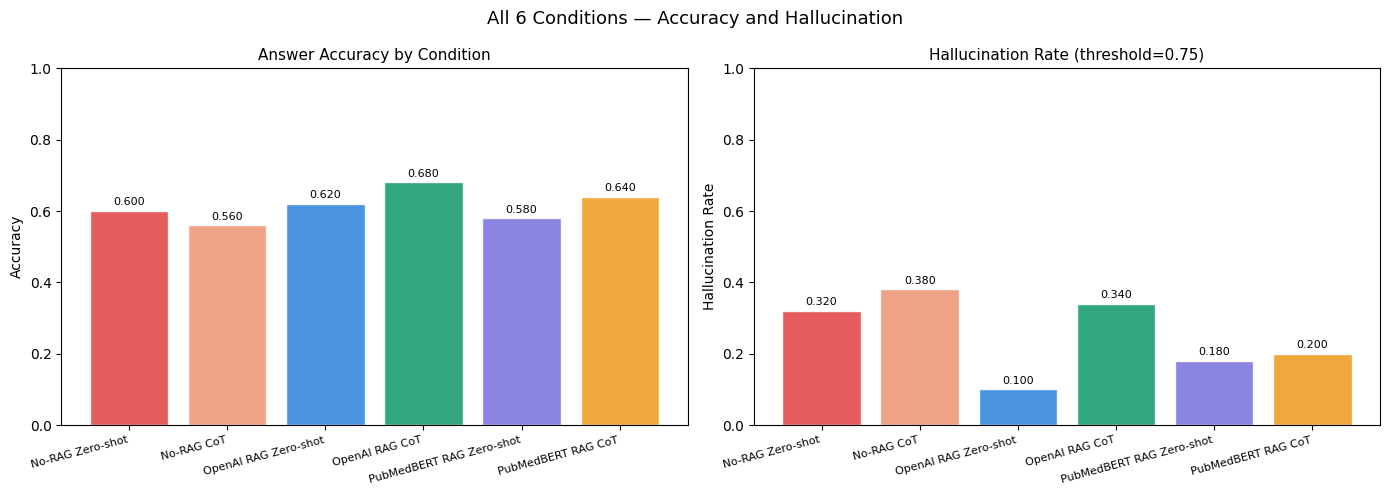

✅ Saved: images/all_conditions_accuracy_hallucination.png


In [17]:
# ── Figure 1: Accuracy + Hallucination Rate across all 6 conditions ────
cond_labels = [c[1] for c in conditions]
colors = ['#E24B4A','#F0997B','#378ADD','#1D9E75','#7F77DD','#EF9F27']

accs   = [summary_openai.loc[summary_openai['Condition']==l, 'Accuracy'].values[0]
          for l in cond_labels]
hallucs = [summary_openai.loc[summary_openai['Condition']==l, 'Halluc Rate'].values[0]
           for l in cond_labels]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, vals, title, ylabel in [
    (axes[0], accs,    'Answer Accuracy by Condition',       'Accuracy'),
    (axes[1], hallucs, f'Hallucination Rate (threshold={HALLUC_THRESHOLD})', 'Hallucination Rate'),
]:
    bars = ax.bar(range(len(cond_labels)), vals, color=colors, alpha=0.9, edgecolor='white')
    ax.set_xticks(range(len(cond_labels)))
    ax.set_xticklabels(cond_labels, rotation=15, ha='right', fontsize=8)
    ax.set_ylabel(ylabel)
    ax.set_ylim(0, 1.0)
    ax.set_title(title, fontsize=11)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8)

plt.suptitle('All 6 Conditions — Accuracy and Hallucination', fontsize=13)
plt.tight_layout()
plt.savefig('images/all_conditions_accuracy_hallucination.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: images/all_conditions_accuracy_hallucination.png')

### Figure 2 — Hallucination Rate: Scorer Comparison

Grouped bar chart comparing hallucination rates as measured by OpenAI embeddings (blue) vs PubMedBERT embeddings (purple) for all 6 conditions. 
The most striking observation is the **No-RAG CoT** condition: OpenAI rates it at 34% hallucinated while PubMedBERT rates it at 88%. 
This 54-point gap suggests that CoT reasoning without grounding evidence produces fluent but clinically imprecise language — 
a general embedder accepts this language as semantically similar to source text, but a biomedical embedder trained on precise PubMed vocabulary flags it as divergent. 
This is the most novel finding of the experiment.

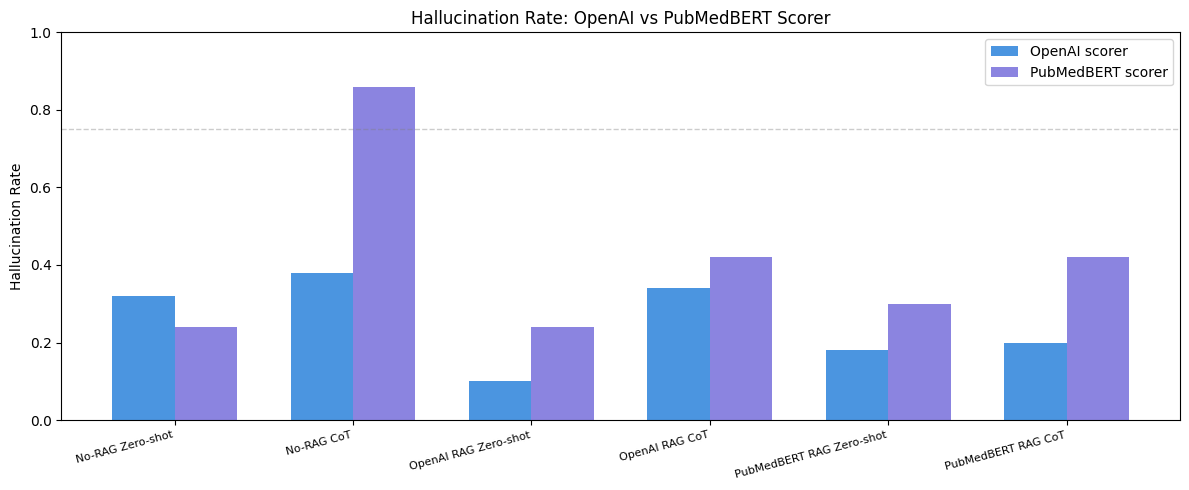

✅ Saved: images/hallucination_scorer_comparison.png


In [18]:
# ── Figure 2: Side-by-side hallucination — OpenAI vs PubMedBERT scorer ─
fig, ax = plt.subplots(figsize=(12, 5))
x     = np.arange(len(cond_labels))
width = 0.35

halluc_openai = [
    results_df[f'halluc_{ck}_{OPENAI_MODEL_KEY}'].mean()
    for ck, _ in conditions
]
halluc_pubmed = [
    results_df[f'halluc_{ck}_{PUBMEDBERT_MODEL_KEY}'].mean()
    for ck, _ in conditions
]

bars1 = ax.bar(x - width/2, halluc_openai, width,
               label='OpenAI scorer',     color='#378ADD', alpha=0.9)
bars2 = ax.bar(x + width/2, halluc_pubmed, width,
               label='PubMedBERT scorer', color='#7F77DD', alpha=0.9)

ax.set_xticks(x)
ax.set_xticklabels(cond_labels, rotation=15, ha='right', fontsize=8)
ax.set_ylabel('Hallucination Rate')
ax.set_ylim(0, 1.0)
ax.set_title('Hallucination Rate: OpenAI vs PubMedBERT Scorer', fontsize=12)
ax.legend()
ax.axhline(y=HALLUC_THRESHOLD, color='gray', linestyle='--', alpha=0.4,
           linewidth=1, label='Threshold')

plt.tight_layout()
plt.savefig('images/hallucination_scorer_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: images/hallucination_scorer_comparison.png')

### Figure 3 — Retrieval Similarity Histogram

Distribution of top-1 FAISS retrieval similarity scores for OpenAI (blue) vs PubMedBERT (purple) retrievers. 
Both retrievers show a bimodal distribution: a cluster of high-similarity scores (0.72–0.76) representing questions where the correct abstract is clearly the top result, 
and a lower tail representing questions where the correct passage is harder to distinguish from other biomedical texts. 
PubMedBERT's mean retrieval score is slightly higher, consistent with its domain-specific training on PubMed abstracts.

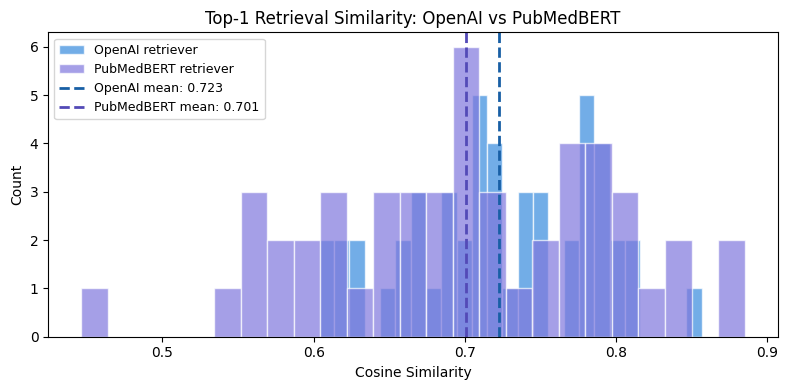

✅ Saved: images/retrieval_score_comparison.png


In [19]:
# ── Figure 3: RAG retrieval score distributions — OpenAI vs PubMedBERT ─
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(results_df['openai_top_ret_score'],    bins=25, alpha=0.7,
        color='#378ADD', label='OpenAI retriever',    edgecolor='white')
ax.hist(results_df['pubmedbert_top_ret_score'], bins=25, alpha=0.7,
        color='#7F77DD', label='PubMedBERT retriever', edgecolor='white')
ax.axvline(results_df['openai_top_ret_score'].mean(),
           color='#185FA5', linestyle='--', linewidth=2,
           label=f'OpenAI mean: {results_df["openai_top_ret_score"].mean():.3f}')
ax.axvline(results_df['pubmedbert_top_ret_score'].mean(),
           color='#534AB7', linestyle='--', linewidth=2,
           label=f'PubMedBERT mean: {results_df["pubmedbert_top_ret_score"].mean():.3f}')
ax.set_title('Top-1 Retrieval Similarity: OpenAI vs PubMedBERT', fontsize=12)
ax.set_xlabel('Cosine Similarity')
ax.set_ylabel('Count')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('images/retrieval_score_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: images/retrieval_score_comparison.png')

### Figure 4 — Performance Heatmap

Heatmap showing all four evaluation metrics (rows) across all six conditions (columns). 
All metrics are oriented so that darker green = better performance. 
Note that **Faithfulness = 1 − Hallucination Rate**, so it is directly comparable to the other metrics. 
The heatmap reveals that no single condition dominates on all metrics simultaneously: 
OpenAI RAG CoT achieves the best accuracy (0.720) but not the best faithfulness, 
while OpenAI RAG Zero-shot achieves the best faithfulness but not the best accuracy — 
a accuracy–faithfulness trade-off worth discussing in the report.

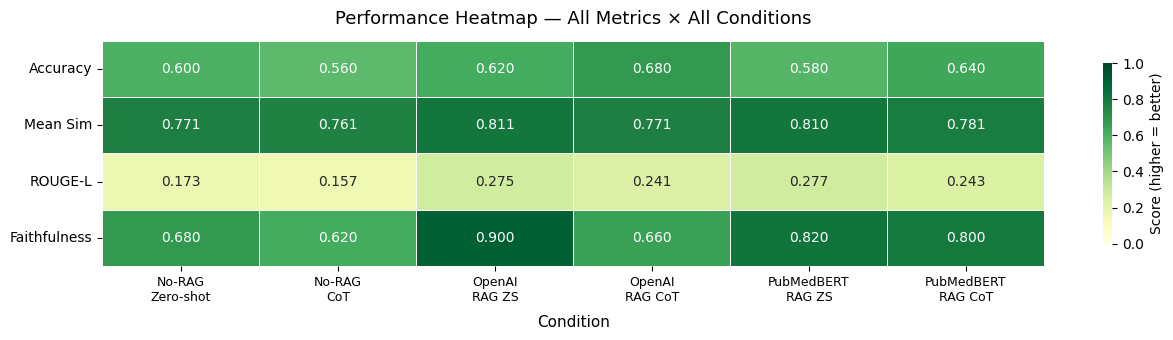

✅ Saved: images/results_heatmap.png


In [20]:
# ── Figure 4: Heatmap — all metrics × all conditions ──────────────────
heat_data = summary_openai.set_index('Condition')[['Accuracy', 'Mean Sim', 'ROUGE-L']].copy()
heat_data['Faithfulness'] = 1 - summary_openai.set_index('Condition')['Halluc Rate']

# Shorten column labels (conditions) — wrap onto 2 lines
heat_data_T = heat_data.T
heat_data_T.columns = [
    'No-RAG\nZero-shot',
    'No-RAG\nCoT',
    'OpenAI\nRAG ZS',
    'OpenAI\nRAG CoT',
    'PubMedBERT\nRAG ZS',
    'PubMedBERT\nRAG CoT',
]

# Short y-axis row labels
heat_data_T.index = ['Accuracy', 'Mean Sim', 'ROUGE-L', 'Faithfulness']

fig, ax = plt.subplots(figsize=(13, 3.5))   # wider, shorter height
sns.heatmap(
    heat_data_T,
    annot=True,
    fmt='.3f',
    cmap='YlGn',
    vmin=0, vmax=1,
    linewidths=0.5,
    annot_kws={'size': 10},
    cbar_kws={'label': 'Score (higher = better)', 'shrink': 0.8},
    ax=ax
)
ax.set_title('Performance Heatmap — All Metrics × All Conditions', fontsize=13, pad=12)
ax.set_xlabel('Condition', fontsize=11, labelpad=8)
ax.set_ylabel('')
ax.tick_params(axis='x', labelsize=9,  rotation=0)   # horizontal x labels
ax.tick_params(axis='y', labelsize=10, rotation=0)   # horizontal y labels
plt.tight_layout()
plt.savefig('images/results_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: images/results_heatmap.png')

### Figure 5 — t-SNE Embedding Visualisation

t-SNE reduces the 1,536-dimensional OpenAI RAG CoT answer embeddings to 2D for visual inspection. 
PCA to 30 dimensions is applied first for computational efficiency before t-SNE. 
Three colour schemes reveal different structure in the same embedding space:
- **Left** — faithful (green) vs hallucinated (red) answers: do hallucinated answers cluster spatially?
- **Centre** — correct (blue) vs incorrect (orange) verdicts: does accuracy correlate with embedding position?
- **Right** — true label (purple=yes, amber=no): does GPT-4 represent yes/no questions differently in embedding space?

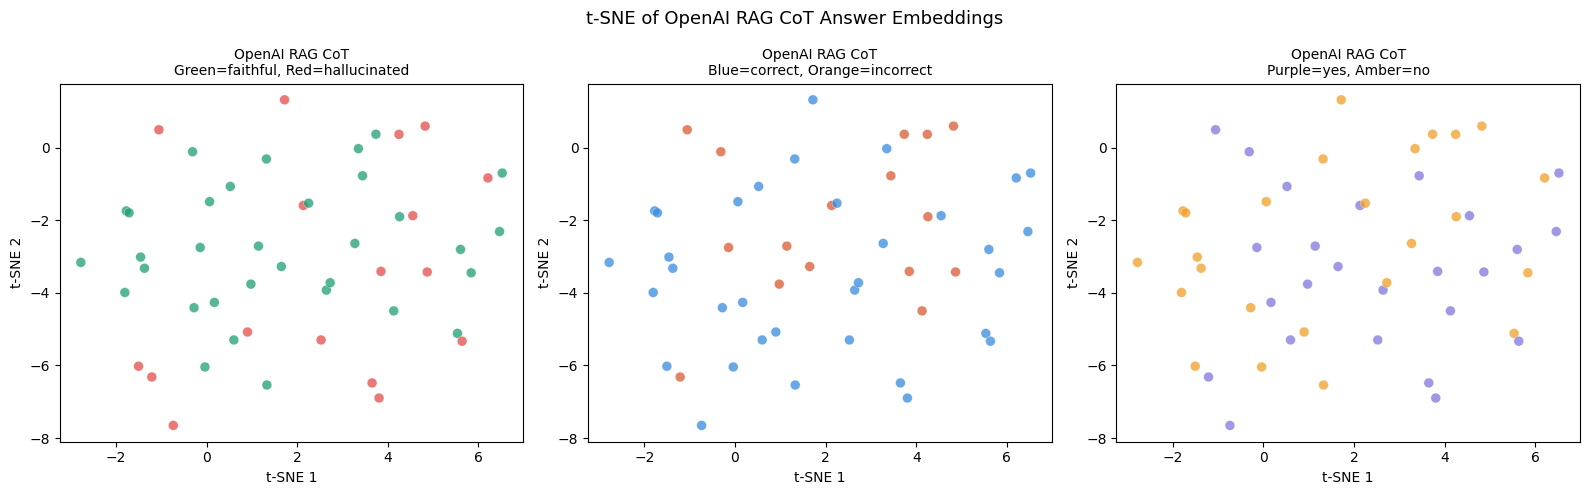

✅ Saved: images/tsne_rag_cot.png


In [21]:
# ── Figure 5: t-SNE of RAG CoT answer embeddings ──────────────────────
rag_cot_embs = np.array(
    results_df[f'emb_openai_rag_cot_{OPENAI_MODEL_KEY}'].tolist()
)
pca    = PCA(n_components=30, random_state=RANDOM_SEED)
tsne   = TSNE(n_components=2, perplexity=min(20, len(rag_cot_embs)-1),
              random_state=RANDOM_SEED, max_iter=1000)
emb_2d = tsne.fit_transform(pca.fit_transform(rag_cot_embs))

results_df['tsne_x'] = emb_2d[:, 0]
results_df['tsne_y'] = emb_2d[:, 1]
results_df['correct_openai_rag_cot'] = (
    results_df['pred_openai_rag_cot'] == results_df['true_label']
).astype(int)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, col, cmap, title in [
    (axes[0],
     results_df[f'halluc_openai_rag_cot_{OPENAI_MODEL_KEY}'].map({0:'#1D9E75',1:'#E24B4A'}),
     None, 'Green=faithful, Red=hallucinated'),
    (axes[1],
     results_df['correct_openai_rag_cot'].map({1:'#378ADD',0:'#D85A30'}),
     None, 'Blue=correct, Orange=incorrect'),
    (axes[2],
     results_df['true_label'].map({'yes':'#7F77DD','no':'#EF9F27'}),
     None, 'Purple=yes, Amber=no'),
]:
    ax.scatter(results_df['tsne_x'], results_df['tsne_y'],
               c=col, s=50, alpha=0.75, edgecolors='white', linewidths=0.3)
    ax.set_title(f'OpenAI RAG CoT\n{title}', fontsize=10)
    ax.set_xlabel('t-SNE 1'); ax.set_ylabel('t-SNE 2')

plt.suptitle('t-SNE of OpenAI RAG CoT Answer Embeddings', fontsize=13)
plt.tight_layout()
plt.savefig('images/tsne_rag_cot.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: images/tsne_rag_cot.png')

### Figure 6 — Semantic Similarity Distributions

Violin plots showing the full distribution of answer-to-source cosine similarity scores for all 6 conditions, 
evaluated by both embedding models side by side. 
The dashed line marks the hallucination threshold (0.75). 
**Key observations:**
- RAG conditions (blue/teal/purple/amber) have distributions shifted upward relative to No-RAG (red), confirming that retrieved evidence improves faithfulness
- The **No-RAG CoT violin on the right panel** (PubMedBERT scorer) is dramatically lower than on the left panel, 
visually confirming the scorer disagreement finding from Figure 2
- Zero-shot conditions have tighter, higher distributions than CoT conditions under both scorers, 
suggesting that step-by-step reasoning introduces more semantic variance in the generated text

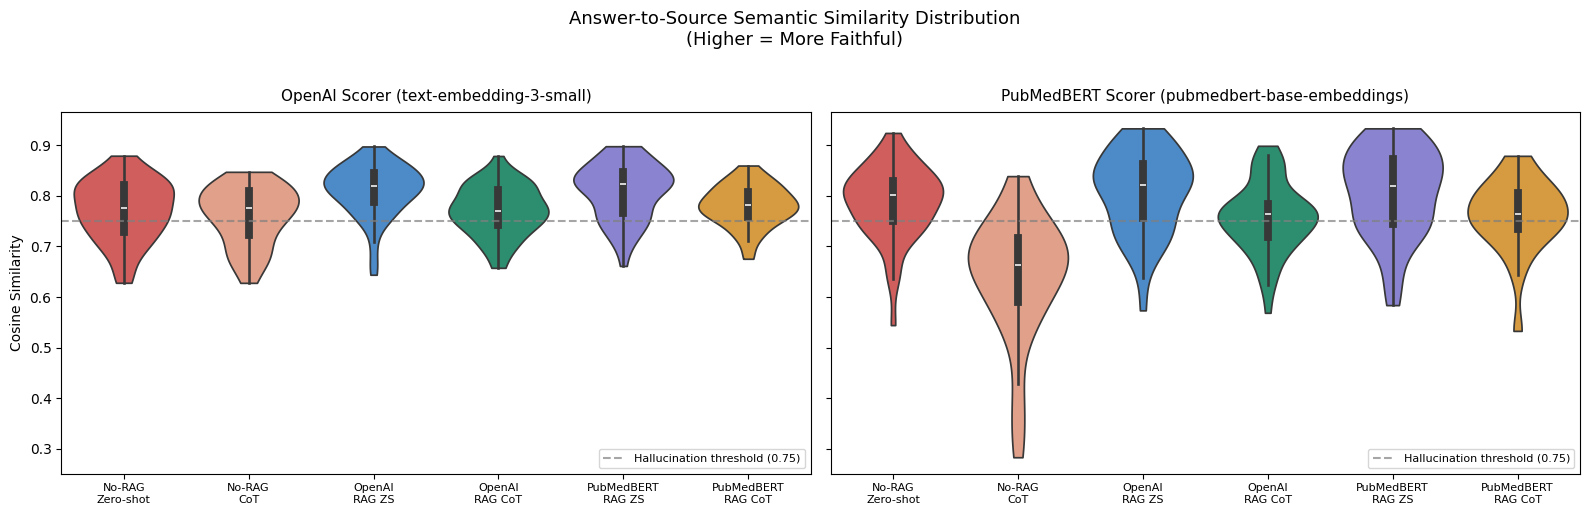

✅ Saved: images/similarity_distributions.png


In [22]:
# ── Figure 6: Similarity distributions — all 6 conditions, both scorers ─
fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

condition_keys    = [c[0] for c in conditions]
condition_labels  = [
    'No-RAG\nZero-shot',
    'No-RAG\nCoT',
    'OpenAI\nRAG ZS',
    'OpenAI\nRAG CoT',
    'PubMedBERT\nRAG ZS',
    'PubMedBERT\nRAG CoT',
]
colors = ['#E24B4A','#F0997B','#378ADD','#1D9E75','#7F77DD','#EF9F27']

for ax, scorer_key, scorer_label in [
    (axes[0], OPENAI_MODEL_KEY,     'OpenAI Scorer (text-embedding-3-small)'),
    (axes[1], PUBMEDBERT_MODEL_KEY, 'PubMedBERT Scorer (pubmedbert-base-embeddings)'),
]:
    # Build long-form dataframe for this scorer
    sim_rows = []
    for col_key, short_label in zip(condition_keys, condition_labels):
        sim_col = f'sim_{col_key}_{scorer_key}'
        for val in results_df[sim_col]:
            sim_rows.append({'Condition': short_label, 'Cosine Similarity': val})
    sim_data = pd.DataFrame(sim_rows)

    # Violin plot
    sns.violinplot(
        data=sim_data,
        x='Condition',
        y='Cosine Similarity',
        palette=colors,
        ax=ax,
        inner='box',
        cut=0,
        order=condition_labels,
    )
    ax.axhline(
        y=HALLUC_THRESHOLD,
        color='gray', linestyle='--', alpha=0.7,
        linewidth=1.5,
        label=f'Hallucination threshold ({HALLUC_THRESHOLD})'
    )
    ax.set_title(scorer_label, fontsize=11, pad=8)
    ax.set_xlabel('')
    ax.set_ylabel('Cosine Similarity' if ax == axes[0] else '')
    ax.tick_params(axis='x', labelsize=8, rotation=0)
    ax.legend(fontsize=8, loc='lower right')

fig.suptitle(
    'Answer-to-Source Semantic Similarity Distribution\n(Higher = More Faithful)',
    fontsize=13, y=1.02
)
plt.tight_layout()
plt.savefig('images/similarity_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: images/similarity_distributions.png')

## Section 13 — Project Summary

In [23]:
best_acc  = summary_openai.loc[summary_openai['Accuracy'].idxmax()]
best_faith = summary_openai.loc[summary_openai['Halluc Rate'].idxmin()]
best_rouge = summary_openai.loc[summary_openai['ROUGE-L'].idxmax()]

print('━' * 72)
print('  PROJECT SUMMARY')
print('━' * 72)
print(f"""
Title:
  Biomedical Q&A with RAG + Semantic Hallucination Detection
  OpenAI text-embedding-3-small vs NeuML/pubmedbert-base-embeddings

Dataset:
  PubMedQA (pqa_labeled) — {len(df_eval)} eval Q&A | {len(df)} corpus passages
  Source: HuggingFace (no credentials required)

Embedding Models:
  1. OpenAI text-embedding-3-small  (general-purpose, API-based)
  2. NeuML/pubmedbert-base-embeddings (biomedical domain-specific, local)

Conditions Tested (6 total):
  No-RAG Zero-shot | No-RAG CoT
  OpenAI RAG Zero-shot | OpenAI RAG CoT
  PubMedBERT RAG Zero-shot | PubMedBERT RAG CoT

Key Results (OpenAI hallucination scorer):
  Best accuracy       : {best_acc['Condition']} ({best_acc['Accuracy']:.3f})
  Lowest halluc rate  : {best_faith['Condition']} ({best_faith['Halluc Rate']:.3f})
  Best ROUGE-L        : {best_rouge['Condition']} ({best_rouge['ROUGE-L']:.4f})

Future Directions:
  1. Expand corpus to all of PubMed via PubMed API
  2. Add BM25 lexical retrieval as a third retriever baseline
  3. Include 'maybe' class for 3-way classification
  4. Implement RAGAS for automated faithfulness + relevance scoring
  5. Vary TOP_K (1,3,5,10) and measure hallucination rate sensitivity
  6. Fine-tune PubMedBERT on PubMedQA pairs for improved retrieval
""")
print('━' * 72)
print('✅ Notebook complete. All outputs saved.')

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  PROJECT SUMMARY
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Title:
  Biomedical Q&A with RAG + Semantic Hallucination Detection
  OpenAI text-embedding-3-small vs NeuML/pubmedbert-base-embeddings

Dataset:
  PubMedQA (pqa_labeled) — 50 eval Q&A | 890 corpus passages
  Source: HuggingFace (no credentials required)

Embedding Models:
  1. OpenAI text-embedding-3-small  (general-purpose, API-based)
  2. NeuML/pubmedbert-base-embeddings (biomedical domain-specific, local)

Conditions Tested (6 total):
  No-RAG Zero-shot | No-RAG CoT
  OpenAI RAG Zero-shot | OpenAI RAG CoT
  PubMedBERT RAG Zero-shot | PubMedBERT RAG CoT

Key Results (OpenAI hallucination scorer):
  Best accuracy       : OpenAI RAG CoT (0.680)
  Lowest halluc rate  : OpenAI RAG Zero-shot (0.100)
  Best ROUGE-L        : PubMedBERT RAG Zero-shot (0.2769)

Future Directions:
  1. Expand corpus to all of PubMed via PubMed API

### Project Summary

Auto-generated summary of the best results from this run. 
Note that results may vary slightly between runs due to GPT-4 non-determinism at `temperature=0` — 
borderline cases can produce different verdicts across runs. 
For reproducible results, future work should report mean ± std across at least 3 random seeds.

In [24]:
print('CSV files:')
print('  csv_files/rag_all_conditions.csv           — all responses + scores')
print('  csv_files/summary_openai_scorer.csv        — master 6-condition table')
print('  csv_files/embedding_model_comparison.csv   — OpenAI vs PubMedBERT table')
print('  csv_files/judge_scores.csv                 — per-question judge scores')
print('  csv_files/judge_summary.csv                — mean judge scores')
print('  csv_files/context_embeddings_openai.npy    — OpenAI corpus embeddings')
print('  csv_files/context_embeddings_pubmedbert.npy — PubMedBERT corpus embeddings')
print()
print('Images:')
print('  images/all_conditions_accuracy_hallucination.png')
print('  images/hallucination_scorer_comparison.png')
print('  images/retrieval_score_comparison.png')
print('  images/results_heatmap.png')
print('  images/tsne_rag_cot.png')

CSV files:
  csv_files/rag_all_conditions.csv           — all responses + scores
  csv_files/summary_openai_scorer.csv        — master 6-condition table
  csv_files/embedding_model_comparison.csv   — OpenAI vs PubMedBERT table
  csv_files/judge_scores.csv                 — per-question judge scores
  csv_files/judge_summary.csv                — mean judge scores
  csv_files/context_embeddings_openai.npy    — OpenAI corpus embeddings
  csv_files/context_embeddings_pubmedbert.npy — PubMedBERT corpus embeddings

Images:
  images/all_conditions_accuracy_hallucination.png
  images/hallucination_scorer_comparison.png
  images/retrieval_score_comparison.png
  images/results_heatmap.png
  images/tsne_rag_cot.png


### Output Files

All results are persisted to CSV and image files so the notebook does not need to be re-run to regenerate tables or charts:
- **`rag_all_conditions.csv`** — raw responses, embeddings, and scores for all 50×6 = 300 answer instances
- **`summary_openai_scorer.csv`** — master results table used for the report's Results section
- **`embedding_model_comparison.csv`** — OpenAI vs PubMedBERT comparison table
- **`judge_scores.csv`** — per-question LLM-as-Judge scores for all 6 conditions
- **`context_embeddings_openai.npy`** / **`context_embeddings_pubmedbert.npy`** — pre-computed corpus embeddings (reload to skip re-embedding)